# CSE 4095 — Class 5 v3
## Feature Engineering → Importance → Selection → Randomized Search
Protect the final test set throughout model development.

## 1. Load and inspect Auto MPG

   rows  columns
0   398        7


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


,column
0,mpg
1,cylinders
2,displacement
3,horsepower
4,weight
5,acceleration
6,model-year


,column,dtype
0,mpg,float64
1,cylinders,int64
2,displacement,float64
3,horsepower,float64
4,weight,int64
5,acceleration,float64
6,model-year,int64


,column,missing_count
0,mpg,0
1,cylinders,0
2,displacement,0
3,horsepower,2
4,weight,0
5,acceleration,0
6,model-year,0


,column,bad_values_coerced_to_nan


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
count,398.000000,398.000000,398.000000,396.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.189394,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.402030,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


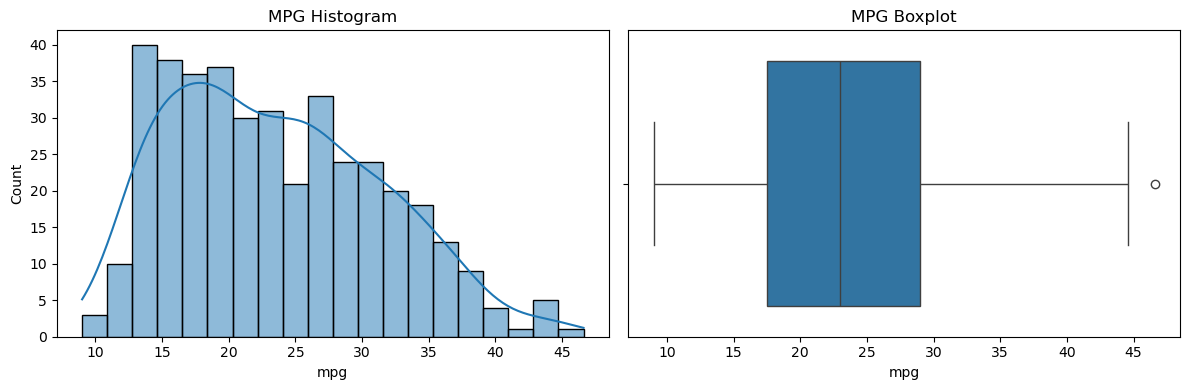

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv"
df = pd.read_csv(url)

object_columns = df.select_dtypes(include="object").columns
coercion_results = []

for column in object_columns:
    cleaned = df[column].replace("?", pd.NA)
    coerced = pd.to_numeric(cleaned, errors="coerce")
    non_missing = cleaned.notna().sum()
    numeric_fraction = coerced.notna().sum() / non_missing if non_missing else 0

    if numeric_fraction >= 0.8:
        affected = int(coerced.isna().sum() - df[column].isna().sum())
        df[column] = coerced
        coercion_results.append({
            "column": column,
            "bad_values_coerced_to_nan": affected
        })

print(pd.DataFrame({"rows": [df.shape[0]], "columns": [df.shape[1]]}))
display(df.head())
display(pd.DataFrame({"column": df.columns}))
display(df.dtypes.rename("dtype").reset_index(name="dtype").rename(columns={"index": "column"}))
display(df.isna().sum().rename("missing_count").reset_index(name="missing_count").rename(columns={"index": "column"}))
display(pd.DataFrame(coercion_results, columns=["column", "bad_values_coerced_to_nan"]))
display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="mpg", bins=20, kde=True, ax=axes[0])
axes[0].set_title("MPG Histogram")
sns.boxplot(data=df, x="mpg", ax=axes[1])
axes[1].set_title("MPG Boxplot")
plt.tight_layout()
plt.show()


**What I noticed:** Each row is one car model, described by its engine and body specs (398 cars, 6 predictors plus the target). The target is mpg. This is a regression problem because mpg is a continuous number, not a category. Any of the six columns (cylinders, displacement, horsepower, weight, acceleration, model-year) could be useful predictors. Only horsepower has missing values (2 rows), and there were no "?" placeholders to clean. The mpg distribution is right-skewed, with most cars between about 15 and 30 mpg and one mild outlier near 47.

## 2. Define X/y and create one train/test split
Use `random_state=42`. Keep the split fixed.

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="mpg")
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(pd.DataFrame({
    "dataset": ["X_train", "X_test", "y_train", "y_test"],
    "shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
}))


,dataset,shape
0,X_train,"(318, 6)"
1,X_test,"(80, 6)"
2,y_train,"(318,)"
3,y_test,"(80,)"


**Why split first:** I made the test set before experimenting so there's a set of data the model-building process never saw. If I checked test MAE while building features, I'd start making choices that fit the test set, and its score would stop being an honest estimate of new data. If I kept changing the model until the test score improved, the score would look good but only because I tuned to those specific 80 cars. So all my decisions use training data and CV, and the test set is saved for the end.

## 3. Mean baseline + untuned Random Forest baseline

In [64]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv_mae(estimator, X_data, y_data, cv=cv):
    scores = cross_validate(
        estimator, X_data, y_data, cv=cv,
        scoring="neg_mean_absolute_error", return_train_score=False
    )["test_score"]
    mae_scores = -scores
    return pd.DataFrame({
        "cv_mae_mean": [mae_scores.mean()],
        "cv_mae_std": [mae_scores.std(ddof=1)],
        "cv_mae_per_fold": [mae_scores]
    })

mean_baseline = Pipeline([
    ("model", DummyRegressor(strategy="mean"))
])
mean_baseline.fit(X_train, y_train)
mean_train_predictions = mean_baseline.predict(X_train)

display(pd.DataFrame({
    "model": ["Training mean baseline"],
    "train_mae": [mean_absolute_error(y_train, mean_train_predictions)],
    "train_rmse": [np.sqrt(mean_squared_error(y_train, mean_train_predictions))],
    "train_r2": [r2_score(y_train, mean_train_predictions)]
}))

mean_cv_results = evaluate_cv_mae(mean_baseline, X_train, y_train)
mean_cv_results.insert(0, "model", "Training mean baseline")
display(mean_cv_results)

# origin is not included because this CSV has no origin column.
original_numeric_features = [
    "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model-year"
]

rf_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_cv_results = evaluate_cv_mae(
    rf_baseline, X_train[original_numeric_features], y_train
)
rf_cv_results.insert(0, "model", "Untuned Random Forest")
display(rf_cv_results)


,model,train_mae,train_rmse,train_r2
0,Training mean baseline,6.68474,7.918095,0.0


,model,cv_mae_mean,cv_mae_std,cv_mae_per_fold
0,Training mean baseline,6.702057,0.504944,"[7.024753937007874, 6.74654281496063, 6.358932..."


,model,cv_mae_mean,cv_mae_std,cv_mae_per_fold
0,Untuned Random Forest,2.003395,0.145597,"[2.123499999999999, 2.021453124999998, 1.77173..."


**What I noticed:** The mean predictor just guesses the training average for every car. It gives a CV MAE of about 6.70, which is the "no skill" floor any real model has to beat. The untuned Random Forest got a CV MAE of about 2.00, so it cuts the error by roughly two thirds. I need this model baseline first so I can tell later whether feature engineering, selection, or tuning actually improved anything.

## 4. Initial feature engineering
Ask AI for candidates first. Choose 2–4 with a rationale before evaluating them.

In [65]:
from sklearn.preprocessing import FunctionTransformer

engineered_feature_names = [
    "power_to_weight",
    "weight_per_cylinder",
    "displacement_per_cylinder"
]

def add_engineered_features(X):
    X_engineered = X.copy()
    safe_weight = X_engineered["weight"].replace(0, np.nan)
    safe_cylinders = X_engineered["cylinders"].replace(0, np.nan)

    X_engineered["power_to_weight"] = X_engineered["horsepower"] / safe_weight
    X_engineered["weight_per_cylinder"] = X_engineered["weight"] / safe_cylinders
    X_engineered["displacement_per_cylinder"] = (
        X_engineered["displacement"] / safe_cylinders
    )
    return X_engineered.replace([np.inf, -np.inf], np.nan)

engineered_feature_transformer = FunctionTransformer(
    add_engineered_features, validate=False
)

X_train_engineered = add_engineered_features(X_train)
display(X_train_engineered[engineered_feature_names].head())

display(pd.DataFrame({
    "feature": engineered_feature_names,
    "nan_count": X_train_engineered[engineered_feature_names].isna().sum().to_numpy(),
    "inf_count": np.isinf(
        X_train_engineered[engineered_feature_names].to_numpy(dtype=float)
    ).sum(axis=0)
}))


,power_to_weight,weight_per_cylinder,displacement_per_cylinder
3,0.043694,429.125,38.00
18,0.041315,532.500,24.25
376,0.033580,506.250,22.75
248,0.033333,450.000,22.75
177,0.035264,673.500,28.75


,feature,nan_count,inf_count
0,power_to_weight,1,0
1,weight_per_cylinder,0,0
2,displacement_per_cylinder,0,0


**Engineered features** (the CSV has no origin or car-name column, so I used the six available predictors. The AI also suggested weight*horsepower and a "vehicle age" feature, which I rejected. See my AI reflection.)

**power_to_weight**
Formula: horsepower / weight
Reasoning: This shows how much engine power a car has relative to its mass. Two cars with the same horsepower can have different fuel economy if one is much heavier.

**weight_per_cylinder**
Formula: weight / cylinders
Reasoning: This separates big heavy cars from small light ones that have the same number of cylinders. A heavy 4-cylinder and a light 4-cylinder probably behave differently on fuel.

**displacement_per_cylinder**
Formula: displacement / cylinders
Reasoning: This is roughly the size of each cylinder. A large-displacement 4-cylinder and a V8 might have similar total displacement but very different engine designs.

Only horsepower has missing values, so power_to_weight has 1 NaN in the training set. The imputer inside the pipeline handles it, and none of the features have inf values.

## 5. Original vs. engineered representation
Keep Random Forest settings and CV procedure fixed.

In [66]:
original_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

engineered_pipeline = Pipeline([
    ("feature_engineering", engineered_feature_transformer),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

original_cv = evaluate_cv_mae(original_pipeline, X_train, y_train)
engineered_cv = evaluate_cv_mae(engineered_pipeline, X_train, y_train)

comparison_results = pd.DataFrame({
    "Feature Set": ["Original", "Original + Engineered"],
    "Mean CV MAE": [
        original_cv.loc[0, "cv_mae_mean"],
        engineered_cv.loc[0, "cv_mae_mean"]
    ],
    "CV Std": [
        original_cv.loc[0, "cv_mae_std"],
        engineered_cv.loc[0, "cv_mae_std"]
    ]
})
display(comparison_results)

per_fold_mae = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),
    "Original MAE": original_cv.loc[0, "cv_mae_per_fold"],
    "Original + Engineered MAE": engineered_cv.loc[0, "cv_mae_per_fold"]
})
display(per_fold_mae)


,Feature Set,Mean CV MAE,CV Std
0,Original,2.003395,0.145597
1,Original + Engineered,2.012579,0.107997


,Fold,Original MAE,Original + Engineered MAE
0,1,2.123500,2.040078
1,2,2.021453,2.122203
2,3,1.771734,1.831219
3,4,2.127619,2.036889
4,5,1.972667,2.032508


**What I noticed:** Feature engineering did not improve CV performance. Mean CV MAE went from 2.003 (original) to 2.013 (original + engineered), a tiny difference far smaller than the fold-to-fold spread. The engineered version was better in 2 folds and worse in 3, and its CV std was lower (0.108 vs 0.146). I can't tell from this whether any single engineered feature helped or hurt. The experiment still told me something: these three ratios didn't add much on top of the raw columns, probably because Random Forests can already learn interactions between features themselves.

## 6. Built-in Random Forest feature importance
Fit the candidate representation, obtain feature names, create a sorted table and plot.

,feature,importance
0,displacement,0.415294
1,horsepower,0.167816
2,cylinders,0.116325
3,weight,0.105979
4,model-year,0.101284
5,weight_per_cylinder,0.030969
6,displacement_per_cylinder,0.026214
7,acceleration,0.019990
8,power_to_weight,0.016130


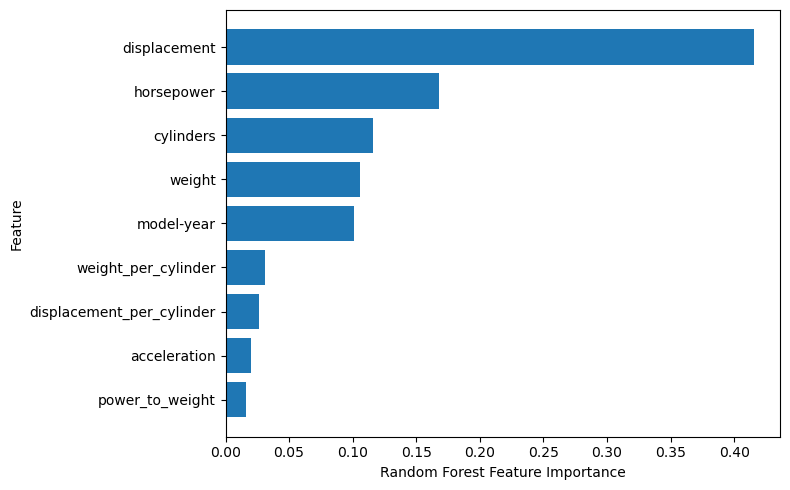

In [67]:
feature_importance_pipeline = Pipeline([
    ("feature_engineering", engineered_feature_transformer),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

feature_importance_pipeline.fit(X_train, y_train)

feature_names = feature_importance_pipeline.named_steps["feature_engineering"].transform(
    X_train.head(0)
).columns.to_list()
feature_importances = feature_importance_pipeline.named_steps["model"].feature_importances_

assert len(feature_names) == len(feature_importances)

feature_importance_results = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance_results)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_results["feature"][::-1],
    feature_importance_results["importance"][::-1]
)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**What I noticed:** Displacement was the most important feature by far (0.415), followed by horsepower (0.168), cylinders, weight, and model-year (around 0.10 to 0.12). The least important were acceleration (0.020) and power_to_weight (0.016). None of the engineered features ranked highly: weight_per_cylinder was 6th, displacement_per_cylinder 7th, and power_to_weight last. What surprised me was how much weight displacement got, and that model-year was only 5th. A low rank doesn't mean a feature is useless, so I'm treating this as a hypothesis to test with CV later.

## 7. Permutation importance
Use validation/training evidence, not the final test set.

/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaco

,feature,importance_mean,importance_std
0,model-year,2.387328,0.161465
1,displacement,2.243157,0.117406
2,horsepower,1.567830,0.087954
3,weight,1.133112,0.059165
4,cylinders,0.510152,0.036522
5,weight_per_cylinder,0.412992,0.029249
6,acceleration,0.388558,0.025078
7,displacement_per_cylinder,0.385281,0.024508
8,power_to_weight,0.279444,0.013212


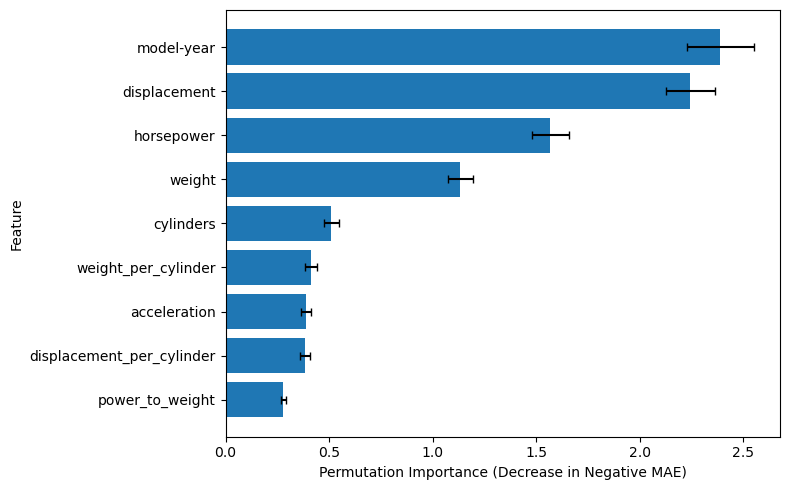

In [68]:
from sklearn.inspection import permutation_importance

X_train_transformed = feature_importance_pipeline[:-1].transform(X_train)
X_train_transformed = pd.DataFrame(
    X_train_transformed, index=X_train.index, columns=feature_names
)

permutation_results = permutation_importance(
    feature_importance_pipeline.named_steps["model"],
    X_train_transformed,
    y_train,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_importance_results = (
    pd.DataFrame({
        "feature": X_train_transformed.columns,
        "importance_mean": permutation_results.importances_mean,
        "importance_std": permutation_results.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(permutation_importance_results)

plot_data = permutation_importance_results.iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"],
    capsize=3
)
plt.xlabel("Permutation Importance (Decrease in Negative MAE)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**What I noticed:** Permutation importance ranked model-year first (about 2.39), then displacement (2.24), horsepower (1.57), and weight (1.13). The lowest were power_to_weight (0.28), displacement_per_cylinder, and acceleration (both about 0.39). This disagrees with the built-in ranking in some places, mainly model-year, which jumped from 5th to 1st. The methods can disagree because built-in importance measures how much a feature reduced error inside the trees and splits credit between correlated features, while permutation importance measures how much MAE gets worse when I shuffle one feature. One caveat is that I computed permutation importance on training data, which the forest has nearly memorized, so these numbers may be a bit inflated.

## 8. Compare importance rankings
Discuss engineered features, correlated predictors, and limitations.

,feature,built_in_importance,built_in_rank,permutation_importance,importance_std,permutation_rank,rank_difference
0,displacement,0.415294,1,2.243157,0.117406,2,-1
1,horsepower,0.167816,2,1.567830,0.087954,3,-1
2,cylinders,0.116325,3,0.510152,0.036522,5,-2
3,weight,0.105979,4,1.133112,0.059165,4,0
4,model-year,0.101284,5,2.387328,0.161465,1,4
5,weight_per_cylinder,0.030969,6,0.412992,0.029249,6,0
6,displacement_per_cylinder,0.026214,7,0.385281,0.024508,8,-1
7,acceleration,0.019990,8,0.388558,0.025078,7,1
8,power_to_weight,0.016130,9,0.279444,0.013212,9,0


,cylinders,displacement,horsepower,weight,acceleration,model-year,power_to_weight,weight_per_cylinder,displacement_per_cylinder
cylinders,1.000000,0.951825,0.840133,0.893808,-0.479743,-0.372146,0.229952,-0.368371,0.773471
displacement,0.951825,1.000000,0.889683,0.929479,-0.512604,-0.384505,0.263499,-0.192490,0.917684
horsepower,0.840133,0.889683,1.000000,0.855188,-0.670291,-0.435830,0.591058,-0.077836,0.797667
weight,0.893808,0.929479,0.855188,1.000000,-0.380938,-0.313227,0.104214,0.065490,0.871669
acceleration,-0.479743,-0.512604,-0.670291,-0.380938,1.000000,0.286697,-0.728439,0.219848,-0.435294
model-year,-0.372146,-0.384505,-0.435830,-0.313227,0.286697,1.000000,-0.349896,0.193622,-0.298780
power_to_weight,0.229952,0.263499,0.591058,0.104214,-0.728439,-0.349896,1.000000,-0.220145,0.187219
weight_per_cylinder,-0.368371,-0.192490,-0.077836,0.065490,0.219848,0.193622,-0.220145,1.000000,0.094502
displacement_per_cylinder,0.773471,0.917684,0.797667,0.871669,-0.435294,-0.298780,0.187219,0.094502,1.000000


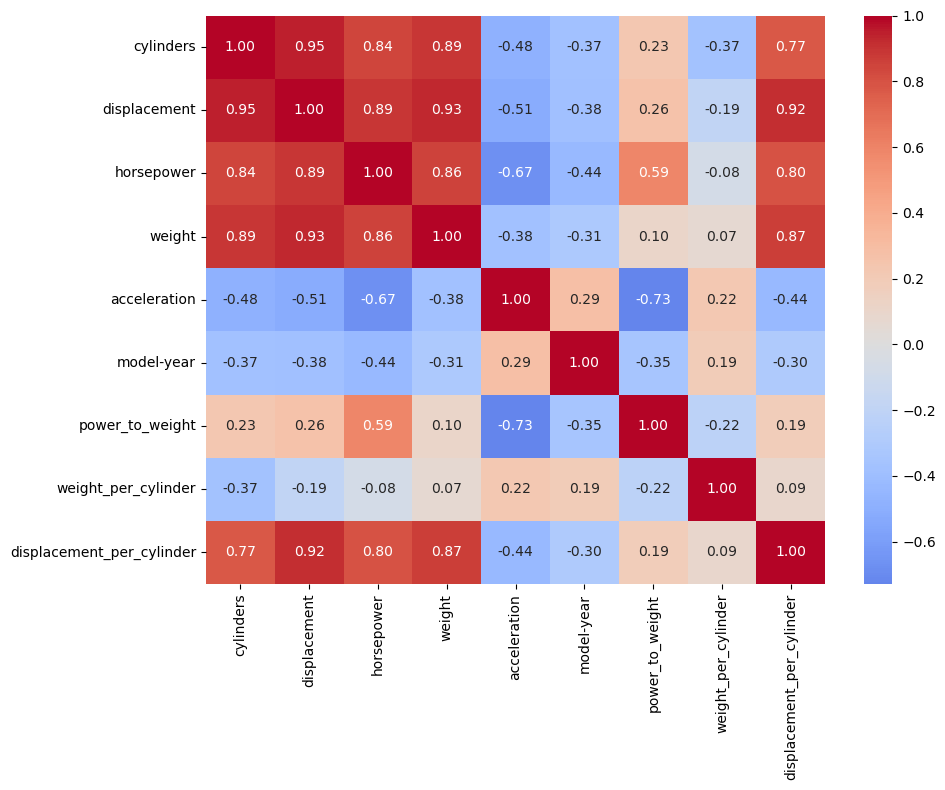

In [69]:
built_in_rankings = feature_importance_results.rename(
    columns={"importance": "built_in_importance"}
).copy()
built_in_rankings["built_in_rank"] = (
    built_in_rankings["built_in_importance"]
    .rank(method="min", ascending=False)
    .astype("Int64")
)

permutation_rankings = permutation_importance_results.rename(
    columns={"importance_mean": "permutation_importance"}
).copy()
permutation_rankings["permutation_rank"] = (
    permutation_rankings["permutation_importance"]
    .rank(method="min", ascending=False)
    .astype("Int64")
)

importance_rank_comparison = (
    built_in_rankings[["feature", "built_in_importance", "built_in_rank"]]
    .merge(
        permutation_rankings[[
            "feature", "permutation_importance", "importance_std", "permutation_rank"
        ]],
        on="feature",
        how="outer"
    )
)
importance_rank_comparison["rank_difference"] = (
    importance_rank_comparison["built_in_rank"]
    - importance_rank_comparison["permutation_rank"]
)
importance_rank_comparison = importance_rank_comparison.sort_values(
    ["built_in_rank", "permutation_rank"], na_position="last"
).reset_index(drop=True)
assert len(importance_rank_comparison) == 9
assert importance_rank_comparison.notna().all().all()
display(importance_rank_comparison)

X_train_with_engineered = add_engineered_features(X_train)
feature_correlation = X_train_with_engineered.corr(numeric_only=True)
display(feature_correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(feature_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.show()


**What I noticed:** Several features overlap a lot. Cylinders, displacement, horsepower, and weight are all correlated at about 0.84 to 0.95, and displacement_per_cylinder is correlated about 0.92 with displacement. When features carry similar information, the forest can use either one, so importance gets split and a useful feature can end up with a low score. Importance also doesn't mean causation. For example, model-year ranks high, but that doesn't mean the year itself changes mpg. It probably stands in for things like regulations and engine technology that changed over time.

## 9. Feature-selection experiment
Create candidate subsets from the importance evidence. Compare with the same CV procedure.

In [70]:
permutation_ranked_features = [
    "model-year",
    "displacement",
    "horsepower",
    "weight",
    "cylinders",
    "weight_per_cylinder",
    "acceleration",
    "displacement_per_cylinder",
    "power_to_weight"
]

feature_subsets = {
    "All 9": permutation_ranked_features,
    "Top 8": permutation_ranked_features[:8],
    "Top 6": permutation_ranked_features[:6],
    "Top 4": permutation_ranked_features[:4],
    "6 Original Raw Features": [
        "cylinders", "displacement", "horsepower", "weight",
        "acceleration", "model-year"
    ]
}

def select_feature_columns(X, columns):
    return X.loc[:, columns]

def make_subset_pipeline(selected_features):
    return Pipeline([
        ("feature_engineering", engineered_feature_transformer),
        ("feature_selection", FunctionTransformer(
            select_feature_columns,
            validate=False,
            kw_args={"columns": selected_features}
        )),
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

subset_rows = []
per_fold_subset_mae = {"Fold": np.arange(1, cv.get_n_splits() + 1)}

for feature_set_name, selected_features in feature_subsets.items():
    subset_cv = evaluate_cv_mae(
        make_subset_pipeline(selected_features), X_train, y_train
    )
    subset_rows.append({
        "Feature Set": feature_set_name,
        "# Features": len(selected_features),
        "Mean CV MAE": subset_cv.loc[0, "cv_mae_mean"],
        "CV Std": subset_cv.loc[0, "cv_mae_std"],
        "Features": ", ".join(selected_features)
    })
    per_fold_subset_mae[feature_set_name] = subset_cv.loc[0, "cv_mae_per_fold"]

feature_subset_results = pd.DataFrame(subset_rows)
display(feature_subset_results)
display(pd.DataFrame(per_fold_subset_mae))


,Feature Set,# Features,Mean CV MAE,CV Std,Features
0,All 9,9,2.002775,0.116852,"model-year, displacement, horsepower, weight, ..."
1,Top 8,8,1.983874,0.128181,"model-year, displacement, horsepower, weight, ..."
2,Top 6,6,2.031650,0.149880,"model-year, displacement, horsepower, weight, ..."
3,Top 4,4,2.042970,0.144669,"model-year, displacement, horsepower, weight"
4,6 Original Raw Features,6,2.003395,0.145597,"cylinders, displacement, horsepower, weight, a..."


,Fold,All 9,Top 8,Top 6,Top 4,6 Original Raw Features
0,1,2.029844,2.049969,2.187406,2.203547,2.123500
1,2,2.096781,2.088375,2.128734,2.108312,2.021453
2,3,1.799375,1.763297,1.795125,1.813719,1.771734
3,4,2.055921,2.025127,2.016667,2.021175,2.127619
4,5,2.031952,1.992603,2.030317,2.068095,1.972667


**What I noticed:** Top 8 had the best mean CV MAE (1.984), slightly better than All 9 (2.003) and the original 6 (2.003). Top 6 (2.032) and Top 4 (2.043) were worse, so the smallest set was not the best. So I could drop power_to_weight, the lowest-ranked feature, without hurting performance. Every difference here is smaller than the CV std (around 0.12 to 0.15), so none of these sets is clearly better than another. If two sets perform almost the same, I'd pick the simpler one, but here Top 8 was both the best and one feature smaller than All 9.

## 10. Optional engineering/selection iteration
Make at most one small follow-up change if the importance results motivate a specific question.

In [71]:
top_6_features = feature_subsets["Top 6"]
top_6_without_cylinders = [
    feature for feature in top_6_features if feature != "cylinders"
]

top_6_cv = evaluate_cv_mae(
    make_subset_pipeline(top_6_features), X_train, y_train
)
top_6_without_cylinders_cv = evaluate_cv_mae(
    make_subset_pipeline(top_6_without_cylinders), X_train, y_train
)

controlled_experiment_results = pd.DataFrame({
    "Feature Set": ["Top 6", "Top 6 without cylinders"],
    "# Features": [len(top_6_features), len(top_6_without_cylinders)],
    "Mean CV MAE": [
        top_6_cv.loc[0, "cv_mae_mean"],
        top_6_without_cylinders_cv.loc[0, "cv_mae_mean"]
    ],
    "CV Std": [
        top_6_cv.loc[0, "cv_mae_std"],
        top_6_without_cylinders_cv.loc[0, "cv_mae_std"]
    ]
})
display(controlled_experiment_results)

display(pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),
    "Top 6 MAE": top_6_cv.loc[0, "cv_mae_per_fold"],
    "Top 6 without cylinders MAE": top_6_without_cylinders_cv.loc[
        0, "cv_mae_per_fold"
    ]
}))


,Feature Set,# Features,Mean CV MAE,CV Std
0,Top 6,6,2.031650,0.149880
1,Top 6 without cylinders,5,2.028639,0.139917


,Fold,Top 6 MAE,Top 6 without cylinders MAE
0,1,2.187406,2.171625
1,2,2.128734,2.109203
2,3,1.795125,1.812797
3,4,2.016667,1.976032
4,5,2.030317,2.073540


**Why engineering comes before selection (Part 12):** In this experiment I removed cylinders from the model input, and CV MAE barely changed (2.032 to 2.029). But weight_per_cylinder and displacement_per_cylinder, both of which need the raw cylinders column, ended up in my final Top 8. If I had judged cylinders as "not important" and dropped it before engineering, I could never have built those two features. Raw features should stay available until after the engineering step.

**Choosing the feature set (Part 13):** I'm going with Top 8. It had the lowest mean CV MAE (1.984), its std (0.128) was in the same range as the others, and it uses one fewer feature than All 9. It drops power_to_weight, which both importance methods ranked last. The gain over All 9 is only about 0.02, which is smaller than the CV std, so this is a reasonable pick and not a proven winner. I didn't use test performance to decide.

## 11. RandomizedSearchCV
Freeze the feature representation first; tune Random Forest on training data only.

**Hyperparameters vs parameters (Part 14):** A hyperparameter is a setting I choose before training, like how many trees to use. A learned parameter is something the model figures out from the data, like the split points inside each tree. RandomizedSearchCV picks a limited number of random combinations from the ranges I give it and scores each with cross-validation. That is cheaper than trying every combination by hand. GridSearchCV tries every combination in the grid, which gets expensive fast as hyperparameters are added.

**My search (Part 15):** I searched 5 hyperparameters with 25 random combinations, 5-fold CV, MAE scoring, and random_state=42. The AI first suggested ranges that included "sqrt" and "log2" for max_features. With only 8 features those two give nearly the same value, so I replaced them with fractions (0.3, 0.5, 0.7, 1.0). I also made max_depth an explicit list that includes None.

**What each hyperparameter does (Part 16):**
- n_estimators: how many trees are in the forest. More trees give more stable predictions but cost more time, and past a point they stop helping.
- max_depth: how many levels each tree can grow. Deeper trees fit the training data more closely and can overfit, and None means no limit.
- max_features: the fraction of features each split is allowed to look at. Lower values make the trees more different from each other, and 1.0 lets every split see everything.
- min_samples_split: the minimum number of rows a node needs before it can be split. Bigger values stop the tree from splitting on tiny groups, so the model is simpler.
- min_samples_leaf: the minimum rows allowed in a final leaf. Bigger values smooth predictions, and 1 lets leaves hold a single car.

In [72]:
from time import perf_counter
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

selected_features = feature_subsets["Top 8"]
print(selected_features)

search_pipeline = Pipeline([
    ("feature_engineering", engineered_feature_transformer),
    ("feature_selection", FunctionTransformer(
        select_feature_columns,
        validate=False,
        kw_args={"columns": selected_features}
    )),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_distributions = {
    "model__n_estimators": randint(200, 801),
    "model__max_depth": [None, 4, 6, 8, 12, 16, 20],
    "model__max_features": [0.3, 0.5, 0.7, 1.0],
    "model__min_samples_split": [2, 4, 6, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 3, 5, 8]
}

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

search_start_time = perf_counter()
random_search.fit(X_train, y_train)
search_total_fit_time = perf_counter() - search_start_time

display(pd.DataFrame({
    "candidates_evaluated": [len(random_search.cv_results_["params"])],
    "total_fit_time_seconds": [search_total_fit_time]
}))


['model-year', 'displacement', 'horsepower', 'weight', 'cylinders', 'weight_per_cylinder', 'acceleration', 'displacement_per_cylinder']


,candidates_evaluated,total_fit_time_seconds
0,25,12.032468


## 12. Inspect search results
Show best parameters, best CV MAE, and top configurations.

In [73]:
print(random_search.best_params_)
print(f"Best CV MAE: {-random_search.best_score_:.4f}")

search_results = pd.DataFrame(random_search.cv_results_)
searched_parameter_columns = [
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__max_features",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf"
]

top_configurations = search_results.sort_values("rank_test_score").head(10).copy()
top_configurations = top_configurations.loc[:, [
    "rank_test_score", "mean_test_score", "std_test_score", "mean_train_score",
    *searched_parameter_columns
]].rename(columns={
    "rank_test_score": "Rank",
    "mean_test_score": "CV MAE",
    "std_test_score": "CV Std",
    "mean_train_score": "train MAE",
    **{column: column.replace("param_model__", "", 1)
       for column in searched_parameter_columns}
}).reset_index(drop=True)
top_configurations[["CV MAE", "train MAE"]] *= -1
display(top_configurations)

best_parameters = random_search.best_params_
edge_ranges = {
    "model__n_estimators": (200, 800),
    "model__max_features": (0.3, 1.0),
    "model__min_samples_split": (2, 20),
    "model__min_samples_leaf": (1, 8)
}
parameter_edge_rows = []
for parameter, value in best_parameters.items():
    parameter_name = parameter.replace("model__", "", 1)
    if parameter == "model__max_depth":
        status = "unbounded option" if value is None else (
            "minimum edge" if value == 4 else "maximum edge" if value == 20 else "interior"
        )
    else:
        minimum, maximum = edge_ranges[parameter]
        status = "minimum edge" if value == minimum else (
            "maximum edge" if value == maximum else "interior"
        )
    parameter_edge_rows.append({
        "hyperparameter": parameter_name,
        "best_value": value,
        "edge_status": status
    })
display(pd.DataFrame(parameter_edge_rows))

untuned_selected_cv = evaluate_cv_mae(
    make_subset_pipeline(selected_features), X_train, y_train
)
tuned_selected_cv = pd.DataFrame({
    "cv_mae_mean": [-random_search.best_score_],
    "cv_mae_std": [
        search_results.loc[random_search.best_index_, "std_test_score"]
    ]
})
untuned_vs_tuned = pd.DataFrame({
    "Model": ["Untuned Random Forest", "Tuned Random Forest"],
    "Mean CV MAE": [
        untuned_selected_cv.loc[0, "cv_mae_mean"],
        tuned_selected_cv.loc[0, "cv_mae_mean"]
    ],
    "CV Std": [
        untuned_selected_cv.loc[0, "cv_mae_std"],
        tuned_selected_cv.loc[0, "cv_mae_std"]
    ]
})
display(untuned_vs_tuned)


{'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 671}
Best CV MAE: 1.9898


,Rank,CV MAE,CV Std,train MAE,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf
0,1,1.989831,0.108595,0.756005,671,None,0.7,2,1
1,2,2.012523,0.105958,1.059602,684,8,1.0,6,1
2,3,2.022335,0.095627,1.278063,591,20,0.7,2,3
3,4,2.041235,0.090324,1.432475,766,16,0.7,10,3
4,5,2.048864,0.080602,1.269205,689,6,0.7,6,1
5,6,2.050652,0.095275,1.402277,361,20,0.5,10,2
6,7,2.053860,0.090895,1.434054,389,6,0.7,10,2
7,8,2.054139,0.096579,1.542505,495,16,0.7,2,5
8,9,2.072351,0.096247,1.578571,589,8,0.5,4,5
9,10,2.093026,0.063522,1.314941,414,12,0.3,6,2


,hyperparameter,best_value,edge_status
0,max_depth,NaN,unbounded option
1,max_features,0.7,interior
2,min_samples_leaf,1.0,minimum edge
3,min_samples_split,2.0,minimum edge
4,n_estimators,671.0,interior


,Model,Mean CV MAE,CV Std
0,Untuned Random Forest,1.983874,0.128181
1,Tuned Random Forest,1.989831,0.108595


**What I noticed:** The best combination was n_estimators=671, max_depth=None, max_features=0.7, min_samples_split=2, min_samples_leaf=1, with a CV MAE of 1.990. The top 10 ranged only from about 1.99 to 2.09, so many combinations were very similar. The best values for min_samples_split (2) and min_samples_leaf (1) sit at the minimum edge, but those are also the lowest values allowed, so there's nothing lower to try. Max_depth=None is the unlimited option. This suggests the forest likes to grow fully with little restriction, which is close to the sklearn defaults. Instead of running another search, I'd next check whether the default config does just as well, and maybe test finer max_features values like 0.6 and 0.8. The train MAE (0.76) is much lower than the CV MAE (1.99), which is normal for a Random Forest.

In [74]:
modeling_stage_results = pd.DataFrame({
    "Stage": [
        "Baseline RF",
        "Feature Engineering",
        "Feature Selection",
        "Randomized Search"
    ],
    "Feature Set / Model": [
        "Original features, untuned Random Forest",
        "Original + engineered features, untuned Random Forest",
        "Selected features, untuned Random Forest",
        "Selected features, tuned Random Forest"
    ],
    "Mean CV MAE": [
        rf_cv_results.loc[0, "cv_mae_mean"],
        engineered_cv.loc[0, "cv_mae_mean"],
        untuned_selected_cv.loc[0, "cv_mae_mean"],
        tuned_selected_cv.loc[0, "cv_mae_mean"]
    ],
    "CV Std": [
        rf_cv_results.loc[0, "cv_mae_std"],
        engineered_cv.loc[0, "cv_mae_std"],
        untuned_selected_cv.loc[0, "cv_mae_std"],
        tuned_selected_cv.loc[0, "cv_mae_std"]
    ]
})
modeling_stage_results["Change vs previous stage"] = (
    modeling_stage_results["Mean CV MAE"].diff()
)
display(modeling_stage_results)


,Stage,Feature Set / Model,Mean CV MAE,CV Std,Change vs previous stage
0,Baseline RF,"Original features, untuned Random Forest",2.003395,0.145597,NaN
1,Feature Engineering,"Original + engineered features, untuned Random...",2.012579,0.107997,0.009185
2,Feature Selection,"Selected features, untuned Random Forest",1.983874,0.128181,-0.028705
3,Randomized Search,"Selected features, tuned Random Forest",1.989831,0.108595,0.005956


**What I noticed:** Feature selection produced the largest change, lowering CV MAE by about 0.029. Feature engineering made it slightly worse (+0.009), and tuning also made it slightly worse (+0.006), so not every step helped. Tuned CV MAE (1.990) was actually a bit higher than the untuned Top 8 (1.984), although the tuned model had a lower std (0.109 vs 0.128). Every one of these changes is much smaller than the CV std, so I wouldn't say any stage meaningfully improved the model. The extra complexity from tuning in particular didn't pay off.

## 12.1 One Additional Experiment

Hypothesis: I expect removing displacement from the Top 8 feature set to change CV MAE by less than the CV standard deviation (about 0.1), because displacement_per_cylinder, cylinders, and weight carry overlapping information (corr of displacement with these is 0.92 to 0.95).

What would count as support: the mean CV MAE changes by less than about 0.1 and the change isn't consistent in direction across all 5 folds.

In [77]:
top_8_features = feature_subsets["Top 8"]
top_8_without_displacement = [
    feature for feature in top_8_features if feature != "displacement"
]

top_8_cv = evaluate_cv_mae(
    make_subset_pipeline(top_8_features), X_train, y_train
)
top_8_without_displacement_cv = evaluate_cv_mae(
    make_subset_pipeline(top_8_without_displacement), X_train, y_train
)

top_8_displacement_experiment = pd.DataFrame({
    "Feature Set": ["Top 8", "Top 8 without displacement"],
    "# Features": [len(top_8_features), len(top_8_without_displacement)],
    "Mean CV MAE": [
        top_8_cv.loc[0, "cv_mae_mean"],
        top_8_without_displacement_cv.loc[0, "cv_mae_mean"]
    ],
    "CV Std": [
        top_8_cv.loc[0, "cv_mae_std"],
        top_8_without_displacement_cv.loc[0, "cv_mae_std"]
    ]
})
display(top_8_displacement_experiment)

top_8_fold_mae = top_8_cv.loc[0, "cv_mae_per_fold"]
top_8_without_displacement_fold_mae = (
    top_8_without_displacement_cv.loc[0, "cv_mae_per_fold"]
)
fold_differences = top_8_without_displacement_fold_mae - top_8_fold_mae
top_8_displacement_per_fold = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),
    "Top 8 MAE": top_8_fold_mae,
    "Top 8 without displacement MAE": top_8_without_displacement_fold_mae,
    "Difference (B - A)": fold_differences
})
display(top_8_displacement_per_fold)

display(pd.DataFrame({
    "mean_difference": [fold_differences.mean()],
    "std_difference": [fold_differences.std(ddof=1)],
    "folds_removing_displacement_worsened_mae": [(fold_differences > 0).sum()]
}))

section_9_top_8 = feature_subset_results.loc[
    feature_subset_results["Feature Set"] == "Top 8"
].iloc[0]
top_8_matches_section_9 = np.isclose(
    top_8_cv.loc[0, "cv_mae_mean"], section_9_top_8["Mean CV MAE"]
) and np.isclose(
    top_8_cv.loc[0, "cv_mae_std"], section_9_top_8["CV Std"]
)
assert top_8_matches_section_9
display(pd.DataFrame({"Top 8 matches Section 9": [top_8_matches_section_9]}))


,Feature Set,# Features,Mean CV MAE,CV Std
0,Top 8,8,1.983874,0.128181
1,Top 8 without displacement,7,2.001387,0.143535


,Fold,Top 8 MAE,Top 8 without displacement MAE,Difference (B - A)
0,1,2.049969,2.107531,0.057563
1,2,2.088375,2.057797,-0.030578
2,3,1.763297,1.754672,-0.008625
3,4,2.025127,2.085603,0.060476
4,5,1.992603,2.001333,0.008730


,mean_difference,std_difference,folds_removing_displacement_worsened_mae
0,0.017513,0.040382,3


,Top 8 matches Section 9
0,True


**Result:** Removing displacement changed mean CV MAE from 1.984 to 2.001, a difference of about 0.018, well under my threshold of 0.1. It was worse in 3 folds and better in 2, so the change wasn't consistent. The fold-to-fold differences had a std of 0.040, so the average change isn't clearly different from zero, though with only 5 folds I can't conclude much. My hypothesis was supported.

**Interpretation:** Observation: removing displacement hardly changed performance. Hypothesis: cylinders, weight, and displacement_per_cylinder (which is built from displacement) carry most of the same information. I didn't test that directly. It's interesting that displacement ranked 2nd in permutation importance, because that shows a high importance score doesn't mean a feature can't be replaced.

## 13. Final held-out test evaluation
Only now evaluate the frozen workflow on the test set.

,Model,MAE,RMSE,R2
0,Training-mean baseline,5.955409,7.347333,-0.004033
1,Tuned Random Forest,1.642999,2.174037,0.912093


,Tuned CV MAE,Tuned Test MAE
0,1.989831,1.642999


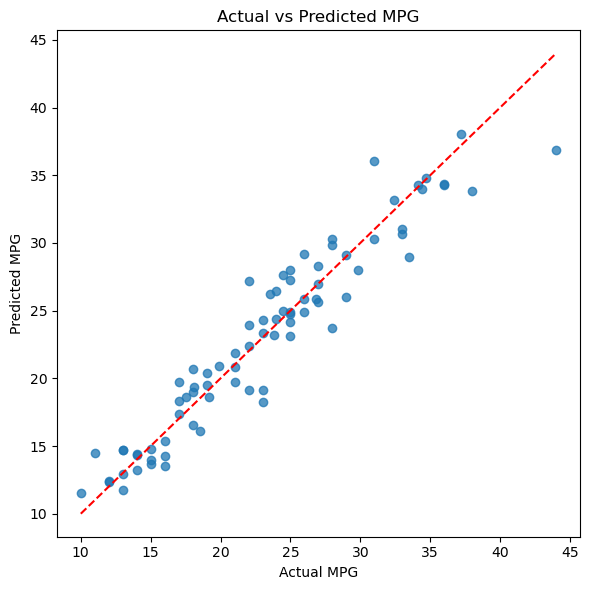

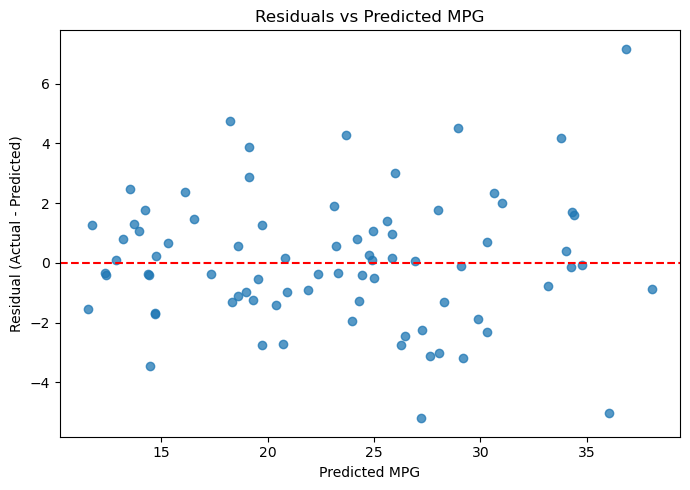

,actual_mpg,predicted_mpg,residual,absolute_error,cylinders,displacement,horsepower,weight,acceleration,model-year,power_to_weight,weight_per_cylinder,displacement_per_cylinder
0,44.0,36.831744,7.168256,7.168256,4,97.0,52.0,2130,24.6,82,0.024413,532.50,24.250000
1,22.0,27.201490,-5.201490,5.201490,6,232.0,112.0,2835,14.7,82,0.039506,472.50,38.666667
2,31.0,36.042176,-5.042176,5.042176,4,91.0,68.0,1970,17.6,82,0.034518,492.50,22.750000
3,23.0,18.246498,4.753502,4.753502,8,350.0,125.0,3900,17.4,79,0.032051,487.50,43.750000
4,33.5,28.966766,4.533234,4.533234,4,98.0,83.0,2075,15.9,77,0.040000,518.75,24.500000
5,28.0,23.703279,4.296721,4.296721,4,140.0,90.0,2264,15.5,71,0.039753,566.00,35.000000
6,38.0,33.801788,4.198212,4.198212,4,91.0,67.0,1965,15.0,82,0.034097,491.25,22.750000
7,23.0,19.133085,3.866915,3.866915,6,198.0,95.0,2904,16.0,73,0.032713,484.00,33.000000
8,11.0,14.464531,-3.464531,3.464531,8,350.0,180.0,3664,11.0,73,0.049127,458.00,43.750000
9,26.0,29.168107,-3.168107,3.168107,4,91.0,70.0,1955,20.5,71,0.035806,488.75,22.750000


In [78]:
tuned_test_predictions = random_search.best_estimator_.predict(X_test)
training_mean_test_predictions = np.full(y_test.shape, y_train.mean())

final_evaluation_results = pd.DataFrame({
    "Model": ["Training-mean baseline", "Tuned Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, training_mean_test_predictions),
        mean_absolute_error(y_test, tuned_test_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, training_mean_test_predictions)),
        np.sqrt(mean_squared_error(y_test, tuned_test_predictions))
    ],
    "R2": [
        r2_score(y_test, training_mean_test_predictions),
        r2_score(y_test, tuned_test_predictions)
    ]
})
display(final_evaluation_results)

tuned_test_mae = mean_absolute_error(y_test, tuned_test_predictions)
display(pd.DataFrame({
    "Tuned CV MAE": [-random_search.best_score_],
    "Tuned Test MAE": [tuned_test_mae]
}))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, tuned_test_predictions, alpha=0.75)
diagonal_limits = [
    min(y_test.min(), tuned_test_predictions.min()),
    max(y_test.max(), tuned_test_predictions.max())
]
plt.plot(diagonal_limits, diagonal_limits, "r--")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.tight_layout()
plt.show()

test_residuals = y_test.to_numpy() - tuned_test_predictions
plt.figure(figsize=(7, 5))
plt.scatter(tuned_test_predictions, test_residuals, alpha=0.75)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted MPG")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted MPG")
plt.tight_layout()
plt.show()

X_test_with_engineered = add_engineered_features(X_test)
test_error_details = pd.concat([
    pd.DataFrame({
        "actual_mpg": y_test,
        "predicted_mpg": tuned_test_predictions,
        "residual": test_residuals,
        "absolute_error": np.abs(test_residuals)
    }, index=X_test.index),
    X_test_with_engineered
], axis=1)
largest_test_errors = (
    test_error_details.nlargest(10, "absolute_error").reset_index(drop=True)
)
display(largest_test_errors)


**Test results (Part 19):** The tuned model got a test MAE of 1.643, RMSE of 2.174, and R2 of 0.912. The mean baseline got an MAE of 5.955, RMSE of 7.347, and R2 of about 0, so the model clearly beat it. Test MAE (1.64) was actually lower than CV MAE (1.99), so the test result is consistent with, and a bit better than, what CV suggested. CV models train on only 80% of the training data and the test set is just 80 cars, so some difference is expected. I don't see signs that my development process overfit.

**Actual vs predicted (Part 20):** Most points sit close to the diagonal. The larger misses are mostly at the high end: the 44 mpg car was predicted at about 37, and a few cars between 28 and 38 mpg were also off. Low-mpg cars (10 to 20) look tighter. So the model seems better at lower and mid-range mpg than at the highest values.

**Residuals (Part 21):** The residuals are scattered around zero without an obvious curve, so there's no strong sign of systematic bias. The spread looks a bit larger for higher predicted values. There may be slightly more over-prediction (negative residuals) around predicted 25 to 30 mpg, but I wouldn't read much into that with only 80 points.

**Largest errors (Part 22):** Case 1, the 44 mpg car (predicted 36.8, residual +7.2). Observation: it has the highest actual mpg in the error table, the lowest horsepower (52), and the highest acceleration value (24.6), and it's a 1982 4-cylinder. Hypothesis: very few training cars look like this, so the forest averages toward more typical mpg values. I can't say a specific feature caused the error.
Case 2, the 8-cylinder 350 displacement car (actual 23, predicted 18.2, residual +4.8). Observation: it's heavy (3900 lb) and the model expected worse mileage than it got. Hypothesis: something not in the dataset, like engine type or tuning, might explain it, but I can't tell from these columns.

## 14. Conclusion + AI Reflection
Explain how engineering changed the representation, what importance suggested, what CV supported removing/keeping, and one AI suggestion you evaluated critically.

### AI Reflection

**Feature suggestions:** I asked the AI for five engineered features with reasoning. It suggested power-to-weight, weight per cylinder, displacement per cylinder, weight horsepower, and a vehicle age feature. I accepted the first three because each has a physical meaning. I rejected the last two: age (max(model-year) minus model-year) is just model-year flipped, which a tree model gains nothing from, and weight horsepower is hard to interpret and overlaps with features I already had. I tested the three I kept with the same 5-fold CV. They didn't improve MAE, which is itself a useful result.

**Search ranges (modified):** I asked the AI for RandomizedSearchCV ranges. It suggested "sqrt" and "log2" for max_features, but with only 8 features those give nearly the same value, so I replaced them with fractions. I also made max_depth an explicit list including None. I checked the result by looking at the top-10 table, which showed several different max_features values being tried.

**Debugging:** The AI's first permutation importance code shuffled the raw columns before engineering, so it only scored 6 features and the 3 engineered ones were missing (they showed up as NaN in my comparison table). I noticed because the table had 6 rows instead of 9. I asked the AI to fix it, and the fixed version scored all 9 features. The AI also made guesses about column names (car name, model_year) that failed, so I told it to check the actual data first.

**Overall:** The AI wrote most of the code, but the decisions came from the CV evidence, for example choosing Top 8 and noting that tuning didn't help.

### Final Workflow Reflection

I started with a baseline so I'd know what "good" looks like (mean predictor 6.70 MAE, untuned RF 2.00). Then I engineered features and compared them using the same CV procedure, looked at both kinds of importance to form hypotheses, and tested several feature subsets with CV before choosing Top 8. After that I tuned the Random Forest with RandomizedSearchCV on the training data only, and evaluated once on the test set (MAE 1.64, R2 0.91).

The order matters because each step relies on the one before it. Engineering has to come before selection so I don't throw away raw columns I need to build features, and I need a baseline to know whether anything helped. Tuning comes last because it depends on which features I'm using. The test set stayed untouched through the split, baselines, engineering, importance, selection, the extra experiment, and the tuning. It was used only once at the very end.

**Link to the AI Agent Chat:**: https://chatgpt.com/s/cx_6ac8815c313c819191f1b752fc31b94f